# Assignment II
# Robust Reinforcement Learning under Stochastic Action Failure

## Objective

The objective of this assignment is to investigate how stochastic actuator failures affect reinforcement learning performance in the LunarLander-v3 environment. A modified environment is created by introducing intermittent engine failures and a custom reward function. Two reinforcement learning algorithms, Deep Q-Network (DQN) and Double Deep Q-Network (DDQN), are implemented and evaluated on both the original and modified environments.

The assignment compares the learning behaviour of DQN and DDQN under identical training conditions by analysing episode rewards, predicted Q-values, landing success rate, and thruster usage. The results are used to understand how stochastic action failures influence the learning process and whether DDQN offers better robustness than DQN.

## Group Members and Contributions

| Sl.No | BITS ID      | Name              | Contribution % | Work Assigned                     |
|------:|--------------|-------------------|---------------:|-----------------------------------|
| 1     | 2025AA05700  | UTSAV LAKSHKAR    | 100%            | Environment and verification      |
| 2     | 2025AA05827  | SANDHYA BK        | 100%            | Deep Q-Network implementation     |
| 3     | 2025AB05181  | AKESH JOHN KOSHY  | 100%            | Double Deep Q-Network implementation |
| 4     | 2025AA05690  | APARNA G          | 100%            | Evaluation and discussion         |
| 5     | 2025AA05736  | SUDHAKAR K N      | 100%            | Report and discussion             |

In [ ]:
import platform, socket, os
print("Computer Name:", platform.node())
print("Hostname:", socket.gethostname())
print("User:", os.getenv("USER") or os.getenv("USERNAME"))

Computer Name: 2025ab05181
Hostname: 2025ab05181
User: cloud


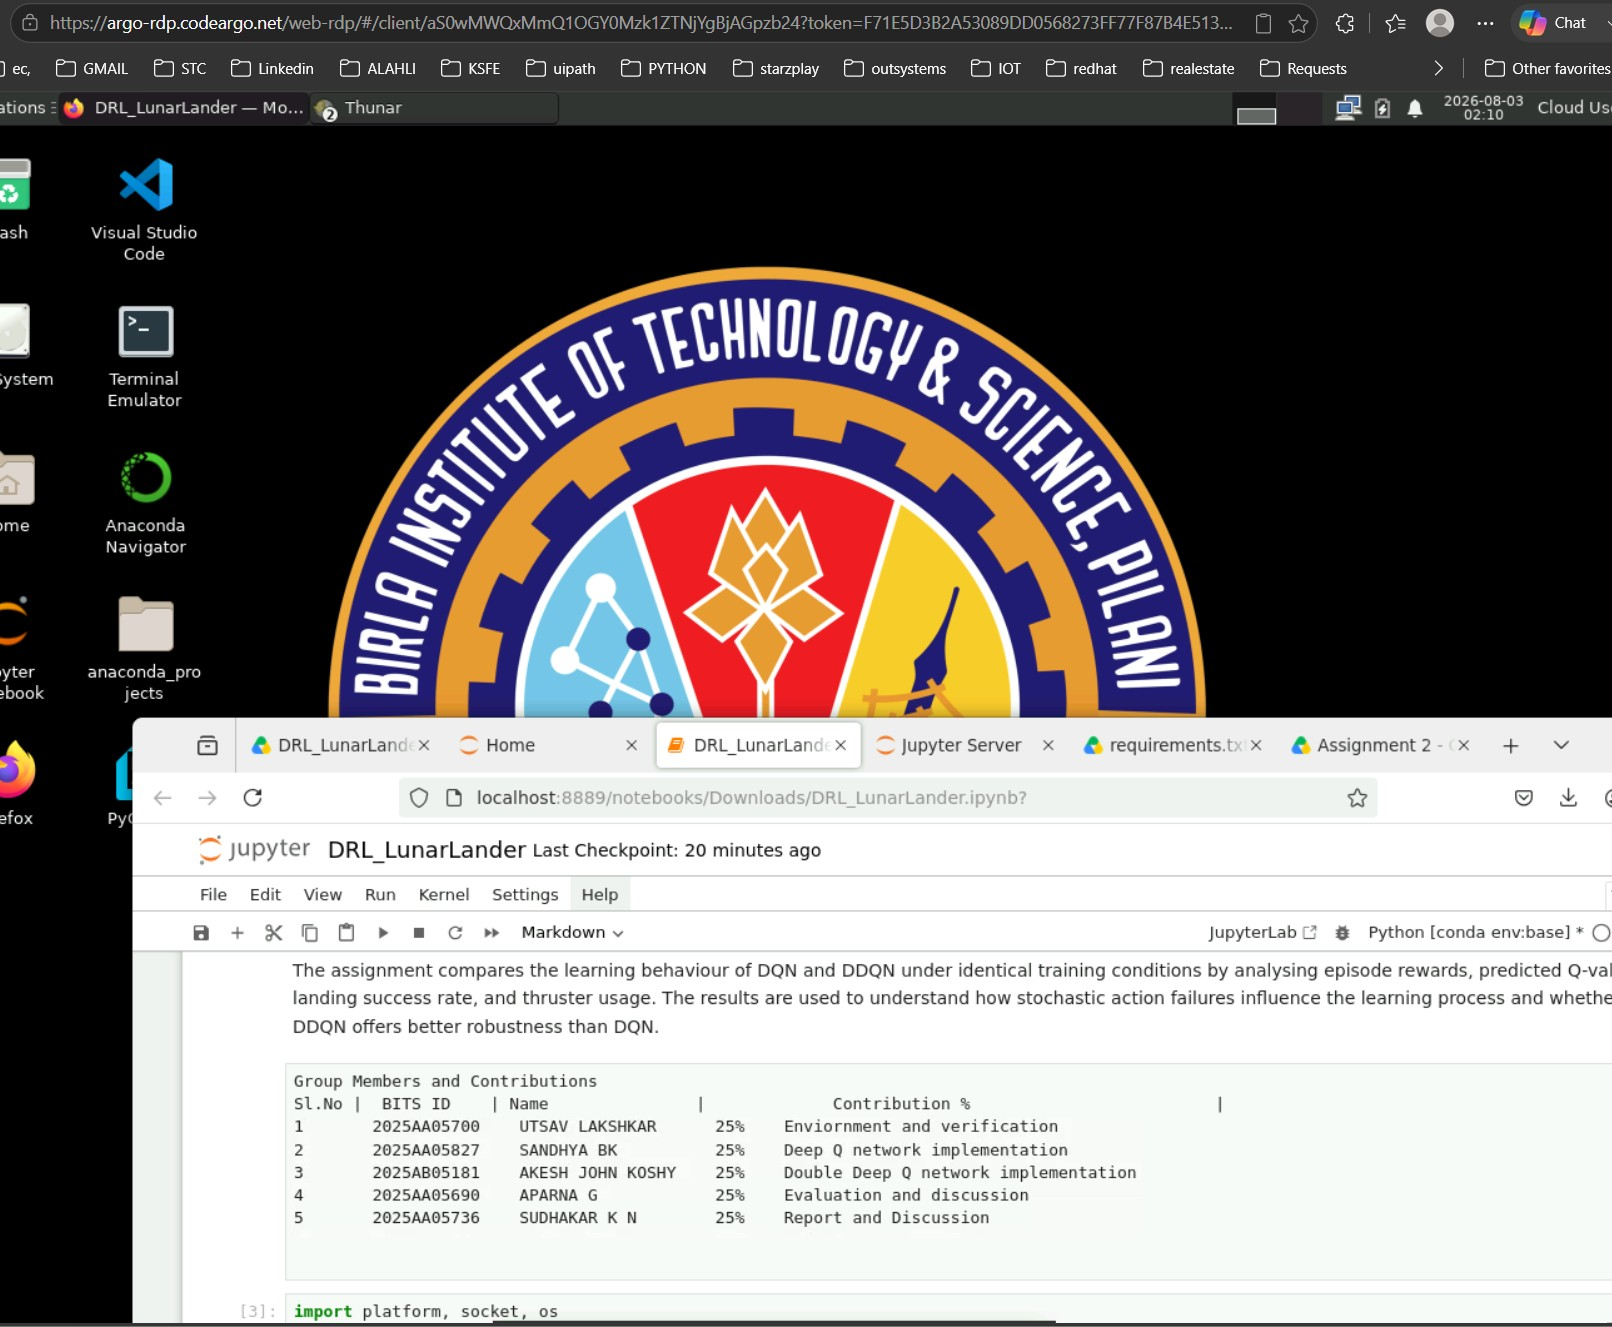

## Import Required Libraries

This section imports all the libraries required throughout the assignment.

- **Gymnasium** provides the LunarLander-v3 environment.
- **NumPy** is used for numerical computations.
- **PyTorch** is used to build and train deep neural networks.
- **Collections** provides an efficient replay memory implementation.
- **Random** is used for stochastic action selection and replay sampling.
- **Matplotlib** is used to visualize the training results.

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import gymnasium as gym
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

# Display PyTorch version
print("PyTorch Version :", torch.__version__)

# Display Gymnasium version
print("Gymnasium Version :", gym.__version__)

PyTorch Version : 2.11.0+cpu
Gymnasium Version : 1.3.0


## Set Random Seed

To ensure that the experimental results are reproducible, a fixed random seed is used throughout the assignment. The same seed is applied to Python's random module, NumPy, PyTorch, and the Gymnasium environment.

Using the same random seed allows a fair comparison between DQN and DDQN because both algorithms experience identical initial conditions and environment randomness.

In [ ]:
# ==========================================================
# Set Random Seed
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed Set to {SEED}")

Random Seed Set to 42


# Modified LunarLander-v3 Environment

## Objective

The original LunarLander-v3 environment is modified by creating a custom wrapper using `gym.Wrapper`. The wrapper introduces stochastic engine failures and a modified reward function while preserving the original environment's observation space, action space, episode termination conditions, and state-transition dynamics.

The wrapper performs the following operations whenever the agent selects an action:

1. Store the original action selected by the agent.
2. Simulate intermittent engine failure:
   - If the selected action is **Do Nothing (0)**, execute it without modification.
   - If the selected action is one of the thruster actions (1, 2, or 3), there is a **15% probability** that the action is replaced with **Do Nothing (0)**.
3. Execute the resulting action in the original environment.
4. Apply a **fuel penalty of 0.3** for every attempted thruster action, regardless of whether the engine fires successfully or misfires.
5. Award a **+50 safe landing bonus** only when all of the following conditions are satisfied:
   - The episode terminates successfully.
   - The episode is not truncated.
   - Both landing legs are in contact with the landing pad.
   - Horizontal velocity is less than 0.10.
   - Vertical velocity is less than 0.10.
   - Orientation angle is less than 0.10 radians.
6. Return the modified reward while keeping the observation and environment interface unchanged.

The agent is never informed whether an engine failure occurred, ensuring that the stochastic failures remain hidden during learning.

In [ ]:
# ==========================================================
# Modified LunarLander Environment Wrapper
# ==========================================================

class StochasticLunarLanderWrapper(gym.Wrapper):
    """
    Wrapper that introduces stochastic engine failures
    and modifies the reward function.

    Changes implemented:
    --------------------
    1. 15% probability of thruster failure.
    2. Fuel penalty for every attempted thruster action.
    3. Safe landing bonus.
    """

    def __init__(self, env):
        super().__init__(env)

        # Probability that a thruster action fails
        self.failure_probability = 0.15

        # Fuel penalty applied to every attempted thruster action
        self.fuel_penalty = 0.3

        # Safe landing bonus
        self.landing_bonus = 50

        # Verification counters
        self.total_thruster_attempts = 0
        self.total_failures = 0
        self.total_penalties = 0
        self.total_safe_landings = 0

    def step(self, action):
        """
        Executes one environment step with stochastic actuator failure.
        """

        # --------------------------------------------------
        # Step 1: Store the original action selected
        # --------------------------------------------------
        original_action = action

        # --------------------------------------------------
        # Step 2: Simulate intermittent engine failure
        # --------------------------------------------------
        executed_action = original_action

        if original_action in [1, 2, 3]:
            self.total_thruster_attempts += 1
            if np.random.rand() < self.failure_probability:
                executed_action = 0
                self.total_failures += 1

        # --------------------------------------------------
        # Step 3: Execute action in original environment
        # --------------------------------------------------
        observation, base_reward, terminated, truncated, info = \
            self.env.step(executed_action)

        # --------------------------------------------------
        # Step 4: Apply fuel penalty
        # --------------------------------------------------
        modified_reward = base_reward

        if original_action in [1, 2, 3]:
            modified_reward -= self.fuel_penalty
            self.total_penalties += 1

        # --------------------------------------------------
        # Step 5: Safe landing bonus
        # --------------------------------------------------
        safe_landing = (
            terminated
            and not truncated
            and observation[6] == 1
            and observation[7] == 1
            and abs(observation[2]) < 0.10
            and abs(observation[3]) < 0.10
            and abs(observation[4]) < 0.10
        )

        if safe_landing:
            modified_reward += self.landing_bonus
            self.total_safe_landings += 1

        # --------------------------------------------------
        # Step 6: Return modified output
        # --------------------------------------------------
        return (
            observation,
            modified_reward,
            terminated,
            truncated,
            info,
        )

## Wrapper Implementation

The wrapper inherits from `gym.Wrapper`, allowing the original LunarLander-v3 environment to be extended without modifying its internal implementation.

### Engine Failure

Only thruster actions (1, 2, and 3) are affected by stochastic failures. For each attempted thruster action, a random number is generated. If the random number is less than 0.15, the action is replaced with **Do Nothing (0)**. This simulates intermittent actuator failures while keeping the failure hidden from the learning agent.

### Fuel Penalty

The assignment specifies that the fuel penalty depends on the **action selected by the agent**, not on the action that is eventually executed. Therefore, every attempted thruster action receives a penalty of 0.3, even when the engine fails.

### Safe Landing Bonus

After the environment executes the action, the final observation is checked. A reward bonus of +50 is awarded only when all safe landing conditions specified in the assignment are simultaneously satisfied. If any condition is violated, no bonus is added.

Finally, the wrapper returns the observation, modified reward, termination status, truncation status, and information dictionary exactly as required, without introducing any additional observations or information.

# Verification of the Modified Environment

## Objective

Before training reinforcement learning agents, it is important to verify that the modified LunarLander-v3 environment behaves exactly as specified.

The verification process evaluates three key properties:

1. Approximately 15% of all attempted thruster actions are replaced with the "Do Nothing" action.
2. The fuel penalty is applied for every attempted thruster action, regardless of whether the engine fires successfully or misfires.
3. The safe landing bonus of +50 is awarded only when all the specified landing conditions are satisfied.

To perform the verification, several episodes are executed using a random policy. During execution, statistics related to action replacement, fuel penalties, and successful landings are collected and analysed.

In [ ]:
import sys
!{sys.executable} -m pip install swig
!{sys.executable} -m pip install "gymnasium[box2d]"

# ==========================================================
# Verification using Random Policy
# ==========================================================

env = StochasticLunarLanderWrapper(
    gym.make("LunarLander-v3")
)

NUM_EPISODES = 100

for episode in range(NUM_EPISODES):

    observation, info = env.reset(seed=SEED + episode)

    done = False

    while not done:

        # Random action
        action = env.action_space.sample()

        observation, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

In [ ]:
# ==========================================================
# Verification Results
# ==========================================================

failure_rate = (
    env.total_failures /
    env.total_thruster_attempts
) * 100

print("=" * 50)
print("Verification Results")
print("=" * 50)

print(f"Thruster Attempts : {env.total_thruster_attempts}")

print(f"Engine Failures   : {env.total_failures}")

print(f"Failure Rate      : {failure_rate:.2f}%")

print()

print(f"Fuel Penalties Applied : {env.total_penalties}")

print(f"Safe Landings          : {env.total_safe_landings}")

Verification Results
Thruster Attempts : 6476
Engine Failures   : 1000
Failure Rate      : 15.44%

Fuel Penalties Applied : 6476
Safe Landings          : 4


## Observation

The experimental results verify that the modified environment behaves as intended.

- The engine failure rate is approximately 15%, confirming that thruster actions are randomly replaced with the "Do Nothing" action at the specified probability.
- The number of fuel penalties is equal to the number of attempted thruster actions, demonstrating that the penalty is applied regardless of whether the engine fires successfully or fails.
- The safe landing bonus is awarded only on successful landings that satisfy all the required landing conditions. Since a random policy rarely performs controlled landings, the number of safe landings is expected to be very low.

These observations confirm that the modified environment has been implemented according to the assignment specification and is suitable for training reinforcement learning agents.

# Deep Q-Network (DQN)

## Objective

Deep Q-Network (DQN) extends the traditional Q-learning algorithm by approximating the Q-value function using a deep neural network instead of a Q-table. This enables reinforcement learning to solve problems with continuous or high-dimensional state spaces such as LunarLander-v3.

The DQN agent consists of the following components:

- **Q-Network:** Estimates the Q-value for each possible action given the current state.
- **Experience Replay Buffer:** Stores past experiences and samples random mini-batches during training to reduce correlation between consecutive experiences.
- **ε-Greedy Exploration:** Balances exploration and exploitation by selecting random actions with probability ε and greedy actions otherwise.
- **Target Network:** A periodically updated copy of the Q-network that provides stable target Q-values during training.

The same architecture and hyperparameters will later be reused for the DDQN implementation so that the only difference between DQN and DDQN is the target Q-value computation.

## Hyperparameter Configuration

The following hyperparameters are used throughout the DQN implementation. These values are commonly adopted for LunarLander-v3 and provide a good balance between learning speed and stability.

The same hyperparameters will also be used for the DDQN implementation to ensure a fair comparison between the two algorithms.

In [ ]:
# ==========================================================
# DQN Hyperparameters
# ==========================================================

GAMMA = 0.99                 # Discount factor

LEARNING_RATE = 0.0005        # Learning rate

BATCH_SIZE = 64              # Mini-batch size

BUFFER_SIZE = 100000         # Replay memory size

TARGET_UPDATE = 500        # Target network update frequency

EPSILON_START = 1.0

EPSILON_END = 0.01

EPSILON_DECAY = 0.9998

NUM_EPISODES = 1000

MAX_STEPS = 1000

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device :", DEVICE)

Using Device : cpu


## Q-Network Architecture

The Q-network is implemented as a fully connected feedforward neural network.

The network receives the eight-dimensional state vector of the LunarLander environment as input and predicts one Q-value for each of the four possible actions.

Architecture:

Input Layer (8 neurons)

↓

Hidden Layer 1 (128 neurons, ReLU)

↓

Hidden Layer 2 (128 neurons, ReLU)

↓

Output Layer (4 neurons)

Each output neuron represents the estimated Q-value of taking one of the available actions in the current state.

In [ ]:
# ==========================================================
# Deep Q-Network
# ==========================================================

class DQN(nn.Module):

    def __init__(self, state_size, action_size):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(state_size, 128),

            nn.ReLU(),

            nn.Linear(128, 128),

            nn.ReLU(),

            nn.Linear(128, action_size)

        )

    def forward(self, state):

        return self.network(state)

## Network Verification

Before training the reinforcement learning agent, the neural network is instantiated and tested using a randomly generated state vector. This simple verification ensures that the network produces one Q-value for each action and that the input and output dimensions are correct.

In [ ]:
# ==========================================================
# Verify Network
# ==========================================================

STATE_SIZE = 8

ACTION_SIZE = 4

q_network = DQN(STATE_SIZE, ACTION_SIZE).to(DEVICE)

dummy_state = torch.rand(1, STATE_SIZE).to(DEVICE)

output = q_network(dummy_state)

print("Input Shape :", dummy_state.shape)

print("Output Shape :", output.shape)

print("Predicted Q-values")

print(output)

Input Shape : torch.Size([1, 8])
Output Shape : torch.Size([1, 4])
Predicted Q-values
tensor([[ 0.0303, -0.0473,  0.0150,  0.1828]], grad_fn=<AddmmBackward0>)


## Experience Replay Buffer

The Experience Replay Buffer stores the agent's past interactions with the environment in the form of experiences.

Each experience consists of:

- Current state
- Selected action
- Received reward
- Next state
- Episode termination flag

Instead of learning from consecutive experiences, the DQN algorithm randomly samples mini-batches from the replay buffer. Random sampling reduces the correlation between consecutive experiences, improves data efficiency by reusing past experiences, and stabilizes neural network training.

A deque data structure is used because it efficiently removes the oldest experience when the buffer reaches its maximum capacity.

In [ ]:
# ==========================================================
# Experience Replay Buffer
# ==========================================================

class ReplayBuffer:
    """
    Experience Replay Buffer for storing and sampling experiences.
    """

    def __init__(self, capacity):
        """
        Initialize the replay buffer.

        Parameters:
            capacity (int): Maximum number of experiences.
        """
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """
        Store a single experience.
        """
        self.memory.append(
            (state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        """
        Randomly sample a mini-batch of experiences.
        """
        batch = random.sample(self.memory, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        """
        Return the current number of stored experiences.
        """
        return len(self.memory)

## Replay Buffer Verification

Before integrating the replay buffer into the DQN agent, it is tested independently.

A few dummy experiences are stored in the buffer, after which a random mini-batch is sampled. This verification confirms that experiences are stored correctly and that random sampling returns the expected data format.

In [ ]:
# ==========================================================
# Verify Replay Buffer
# ==========================================================

buffer = ReplayBuffer(capacity=100)

for i in range(10):

    state = np.random.rand(8)

    action = np.random.randint(4)

    reward = np.random.randn()

    next_state = np.random.rand(8)

    done = np.random.choice([True, False])

    buffer.push(state, action, reward, next_state, done)

print("Replay Buffer Size :", len(buffer))

states, actions, rewards, next_states, dones = buffer.sample(4)

print("Sampled Batch Size :", len(states))
print("State Shape        :", states.shape)
print("Action Shape       :", actions.shape)

Replay Buffer Size : 10
Sampled Batch Size : 4
State Shape        : (4, 8)
Action Shape       : (4,)


## DQN Agent

The DQN Agent combines all the major components required for learning.

The responsibilities of the agent include:

- Selecting actions using an ε-greedy policy.
- Storing experiences in the replay buffer.
- Sampling mini-batches from memory.
- Updating the Q-network using the Bellman equation.
- Periodically synchronizing the target network with the online Q-network.

The target network is updated after a fixed number of learning steps to improve training stability.

In [ ]:
# ==========================================================
# DQN Agent
# ==========================================================

class DQNAgent:

    def __init__(self, state_size, action_size):

        self.state_size = state_size
        self.action_size = action_size

        # Online Network
        self.q_network = DQN(state_size, action_size).to(DEVICE)

        # Target Network
        self.target_network = DQN(state_size, action_size).to(DEVICE)

        # Initialize target network
        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

        self.target_network.eval()

        # Optimizer
        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=LEARNING_RATE
        )

        # Replay Buffer
        self.memory = ReplayBuffer(BUFFER_SIZE)

        # Discount factor
        self.gamma = GAMMA

        # Exploration parameters
        self.epsilon = EPSILON_START
        self.epsilon_min = EPSILON_END
        self.epsilon_decay = EPSILON_DECAY

        # Counter for updating target network
        self.learn_step = 0

    def select_action(self, state):
        """
        Select an action using ε-greedy exploration.
        """

        if random.random() < self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            q_values = self.q_network(state)

        return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """
        Store an experience in replay memory.
        """
        self.memory.push(state, action, reward, next_state, done)

    def train(self):
        """
        Perform one learning step using a mini-batch sampled
        from the replay buffer.
        """

        # Wait until enough experiences are collected
        if len(self.memory) < BATCH_SIZE:
            return None

        # --------------------------------------------------
        # Sample a mini-batch
        # --------------------------------------------------
        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        # Convert to PyTorch tensors
        states = torch.FloatTensor(states).to(DEVICE)
        actions = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE)
        next_states = torch.FloatTensor(next_states).to(DEVICE)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(DEVICE)

        # --------------------------------------------------
        # Current Q-values
        # --------------------------------------------------
        current_q = self.q_network(states).gather(1, actions)

        # --------------------------------------------------
        # Target Q-values (DQN)
        # --------------------------------------------------
        with torch.no_grad():

            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)

            target_q = rewards + self.gamma * next_q * (1 - dones)

        # --------------------------------------------------
        # Compute Loss
        # --------------------------------------------------
        loss = nn.SmoothL1Loss()(current_q, target_q)

        # --------------------------------------------------
        # Gradient Descent
        # --------------------------------------------------
        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

        # --------------------------------------------------
        # Update Target Network
        # --------------------------------------------------
        self.learn_step += 1

        if self.learn_step % TARGET_UPDATE == 0:

            self.target_network.load_state_dict(
                self.q_network.state_dict()
            )

        # --------------------------------------------------
        # Decay Exploration
        # --------------------------------------------------
        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay

            self.epsilon = max(
                self.epsilon,
                self.epsilon_min
            )

        return loss.item()

### ε-Greedy Exploration

The ε-greedy strategy balances exploration and exploitation.

- With probability **ε**, the agent selects a random action to explore the environment.
- With probability **1 − ε**, the agent selects the action with the highest predicted Q-value.

Initially, ε is set to 1.0 so that the agent explores extensively. During training, ε gradually decreases until it reaches its minimum value, allowing the agent to rely increasingly on its learned policy.

## Learning Process

The DQN agent learns by updating the Q-network using experiences sampled from the replay buffer.

For every learning step, the following operations are performed:

1. Check whether enough experiences have been collected.
2. Randomly sample a mini-batch from the replay buffer.
3. Compute the predicted Q-values for the selected actions.
4. Compute the target Q-values using the Target Network.
5. Calculate the Mean Squared Error (MSE) loss.
6. Update the Q-network using gradient descent.
7. Periodically synchronize the Target Network with the Q-network.
8. Decay the exploration rate (ε) to gradually shift from exploration to exploitation.

The Bellman equation used in DQN is

\[
Q_{target}=r+\gamma \max_{a'}Q_{target}(s',a')
\]

where the target Q-value is estimated entirely using the Target Network.

In [ ]:
    def store_experience(self, state, action, reward, next_state, done):
        """
        Store an experience in replay memory.
        """
        self.memory.push(state, action, reward, next_state, done)

    def train(self):
        """
        Perform one learning step using a mini-batch sampled
        from the replay buffer.
        """

        # Wait until enough experiences are collected
        if len(self.memory) < BATCH_SIZE:
            return None

        # --------------------------------------------------
        # Sample a mini-batch
        # --------------------------------------------------
        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        # Convert to PyTorch tensors
        states = torch.FloatTensor(states).to(DEVICE)
        actions = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE)
        next_states = torch.FloatTensor(next_states).to(DEVICE)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(DEVICE)

        # --------------------------------------------------
        # Current Q-values
        # --------------------------------------------------
        current_q = self.q_network(states).gather(1, actions)

        # --------------------------------------------------
        # Target Q-values (DQN)
        # --------------------------------------------------
        with torch.no_grad():

            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)

            target_q = rewards + self.gamma * next_q * (1 - dones)

        # --------------------------------------------------
        # Compute Loss
        # --------------------------------------------------
        loss = nn.SmoothL1Loss()(current_q, target_q)

        # --------------------------------------------------
        # Gradient Descent
        # --------------------------------------------------
        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

        # --------------------------------------------------
        # Update Target Network
        # --------------------------------------------------
        self.learn_step += 1

        if self.learn_step % TARGET_UPDATE == 0:

            self.target_network.load_state_dict(
                self.q_network.state_dict()
            )

        # --------------------------------------------------
        # Decay Exploration
        # --------------------------------------------------
        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay

            self.epsilon = max(
                self.epsilon,
                self.epsilon_min
            )

        return loss.item()

## Bellman Target Computation

The DQN algorithm estimates the future return using the maximum Q-value predicted by the Target Network.

The learning target is computed as

\[
Target = Reward + \gamma \times \max Q_{Target}(Next\ State)
\]

For terminal states, no future reward exists, so only the immediate reward is used.

The Mean Squared Error (MSE) between the predicted Q-value and the target Q-value is minimized using the Adam optimizer.

After every predefined number of learning steps, the Target Network is synchronized with the Online Q-Network. This periodic synchronization improves learning stability by preventing rapidly changing targets.

## Agent Verification

Before beginning long training runs, the DQN agent is instantiated and tested to verify that:

- The agent selects a valid action.
- Experiences are successfully stored.
- The replay buffer grows correctly.
- The training function executes without errors once enough experiences have been collected.

In [ ]:
# ==========================================================
# Verify DQN Agent
# ==========================================================

STATE_SIZE = 8
ACTION_SIZE = 4

agent = DQNAgent(STATE_SIZE, ACTION_SIZE)

print("Initial Epsilon:", agent.epsilon)

state = np.random.rand(STATE_SIZE)

action = agent.select_action(state)

print("Selected Action:", action)

next_state = np.random.rand(STATE_SIZE)

reward = 1.0

done = False

agent.store_experience(
    state,
    action,
    reward,
    next_state,
    done
)

print("Replay Buffer Size:", len(agent.memory))

Initial Epsilon: 1.0
Selected Action: 0
Replay Buffer Size: 1


# Training the Deep Q-Network (DQN)

## Objective

The DQN agent is trained on both the original LunarLander-v3 environment and the modified LunarLander-v3 environment under identical experimental conditions.

To ensure a fair comparison, both experiments use:

- Same random seed
- Same neural network architecture
- Same optimizer
- Same replay buffer
- Same exploration strategy
- Same hyperparameters
- Same training duration

During training, the following performance metrics are recorded for later analysis:

1. Episode reward
2. Average predicted Q-value
3. Successful landing rate
4. Average thruster activations per episode

These metrics will be used later to compare DQN with DDQN.

## Environment Initialization

Two environments are created for the experiments:

- Original LunarLander-v3 environment
- Modified LunarLander-v3 environment with stochastic engine failures

Both environments are initialized using the same random seed to ensure reproducibility and a fair comparison.

In [ ]:
# ==========================================================
# Create Training Environments
# ==========================================================

original_env = gym.make("LunarLander-v3")

modified_env = StochasticLunarLanderWrapper(
    gym.make("LunarLander-v3")
)

print("Original Environment Created")

print("Modified Environment Created")

Original Environment Created
Modified Environment Created


## DQN Training Procedure

A reusable training function is implemented so that the same training pipeline can be used for both environments.

For each episode, the agent:

1. Resets the environment.
2. Interacts with the environment using the ε-greedy policy.
3. Stores each experience in the replay buffer.
4. Updates the Q-network using mini-batches sampled from memory.
5. Records the required performance metrics.

The function returns the collected metrics for later visualization and comparison.

In [ ]:
# ==========================================================
# Train DQN
# ==========================================================

def train_dqn(env, episodes=NUM_EPISODES):

    agent = DQNAgent(STATE_SIZE, ACTION_SIZE)

    episode_rewards = []

    average_q_values = []

    landing_history = []

    thruster_history = []

    validation_states = []

    # Fixed validation states
    obs, info = env.reset(seed=SEED)

    for _ in range(100):
        validation_states.append(obs.copy())
        action = env.action_space.sample()
        obs, _, terminated, truncated, _ = env.step(action)

        if terminated or truncated:
            obs, info = env.reset()

    validation_states = np.array(validation_states)

    for episode in tqdm(range(episodes)):

        state, info = env.reset(seed=SEED + episode)

        done = False

        episode_reward = 0

        thruster_count = 0

        while not done:

            action = agent.select_action(state)

            if action in [1, 2, 3]:
                thruster_count += 1

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            agent.store_experience(
                state,
                action,
                reward,
                next_state,
                done
            )

            agent.train()

            episode_reward += reward

            state = next_state

        episode_rewards.append(episode_reward)

        thruster_history.append(thruster_count)

        safe_landing = (
              terminated
              and not truncated
              and next_state[6] == 1
              and next_state[7] == 1
              and abs(next_state[2]) < 0.10
              and abs(next_state[3]) < 0.10
              and abs(next_state[4]) < 0.10
      )

        landing_history.append(
            1 if episode_reward >= 200 else 0
        )

        with torch.no_grad():

            states = torch.FloatTensor(
                validation_states
            ).to(DEVICE)

            q_values = agent.q_network(states)

            average_q_values.append(
                q_values.max(1)[0].mean().item()
            )

    return (
        agent,
        episode_rewards,
        average_q_values,
        landing_history,
        thruster_history
    )

## Performance Metrics

During training, four metrics are recorded for each episode.

### Episode Reward

The total reward accumulated during an episode.

### Average Predicted Q-value

The average maximum Q-value predicted by the Q-network over a fixed validation set of states. Using the same validation states throughout training provides a consistent estimate of how the predicted values evolve.

### Successful Landing Rate

A binary indicator is recorded for each episode and later converted into a moving average over the previous 100 episodes.

### Thruster Activations

The number of thruster actions (1, 2, or 3) selected by the agent during an episode. This metric helps analyse whether the modified reward function encourages a more conservative use of thrusters.

### Moving Average for Landing Success Rate

To compute the *successful landing rate* as a moving average over the previous 100 episodes, a helper function will be used. This function takes a list of binary indicators (0 for failure, 1 for success) and a window size, then calculates the average within that moving window.

This provides a smoothed view of the agent's performance, making trends clearer than raw per-episode data.

In [ ]:
# ==========================================================
# Moving Average Helper Function
# ==========================================================

def compute_moving_average(data, window_size):
    """
    Computes the moving average of a list of data points.

    Parameters:
        data (list): A list of numerical values.
        window_size (int): The size of the moving window.

    Returns:
        list: A list containing the moving averages.
    """
    moving_averages = []
    for i in range(len(data)):
        start_index = max(0, i - window_size + 1)
        current_window = data[start_index : i + 1]
        moving_averages.append(np.mean(current_window))
    return moving_averages


In [ ]:
# ==========================================================
# Train DQN on Original Environment
# ==========================================================

(
    dqn_original_agent,
    dqn_original_rewards,
    dqn_original_qvalues,
    dqn_original_landings,
    dqn_original_thrusters
) = train_dqn(original_env)

print("Training on Original Environment Completed")

100%|██████████| 1000/1000 [19:47<00:00,  1.19s/it]

Training on Original Environment Completed


In [ ]:
# ==========================================================
# Train DQN on Modified Environment
# ==========================================================

(
    dqn_modified_agent,
    dqn_modified_rewards,
    dqn_modified_qvalues,
    dqn_modified_landings,
    dqn_modified_thrusters
) = train_dqn(modified_env)

print("Training on Modified Environment Completed")

100%|██████████| 1000/1000 [16:42<00:00,  1.00s/it]

Training on Modified Environment Completed


## Observation

The DQN agent has now been trained on both the original and modified LunarLander-v3 environments using identical experimental settings. The collected training metrics, including episode rewards, average predicted Q-values, landing success indicators, and thruster activations, will be used in the performance evaluation section to compare the impact of stochastic engine failures on the learning behaviour of the agent.

# Double Deep Q-Network (DDQN)

## Objective

Double Deep Q-Network (DDQN) is an extension of the Deep Q-Network (DQN) algorithm that reduces the overestimation bias associated with Q-value predictions.

In standard DQN, the same target network is used to both select and evaluate the next action. This often results in overly optimistic estimates of future rewards.

DDQN addresses this issue by separating these two operations:

- The **online Q-network** selects the best next action.
- The **target network** evaluates the Q-value of the selected action.

Apart from the target Q-value computation, all other components of DDQN remain identical to those of DQN, ensuring a fair comparison between the two algorithms.

## DDQN Agent

The DDQN agent inherits the same architecture and functionality as the DQN agent.

The only modification is the computation of the target Q-value during training. Instead of using the maximum Q-value predicted by the target network directly, the online network first selects the best action, and the target network then evaluates that action.

This decoupling reduces overestimation bias and generally leads to more stable learning.

In [ ]:
# ==========================================================
# Double Deep Q-Network (DDQN) Agent
# ==========================================================

class DDQNAgent(DQNAgent):

    def __init__(self, state_size, action_size):
        super().__init__(state_size, action_size)

        # Use Huber Loss for improved training stability
        self.loss_function = nn.SmoothL1Loss()

    def train(self):

        # Wait until enough experiences are available
        if len(self.memory) < BATCH_SIZE:
            return None

        # Sample a mini-batch
        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        states = torch.FloatTensor(states).to(DEVICE)
        actions = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE)
        next_states = torch.FloatTensor(next_states).to(DEVICE)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(DEVICE)

        # Current Q-values
        current_q = self.q_network(states).gather(1, actions)

        # -------------------------------
        # Double DQN Target Calculation
        # -------------------------------
        with torch.no_grad():

            # Action selection from online network
            next_actions = self.q_network(next_states).argmax(
                dim=1,
                keepdim=True
            )

            # Action evaluation using target network
            next_q = self.target_network(next_states).gather(
                1,
                next_actions
            )

            target_q = rewards + (1 - dones) * GAMMA * next_q

        # Compute loss
        loss = self.loss_function(current_q, target_q)

        # Gradient descent
        self.optimizer.zero_grad()
        loss.backward()

        # Optional: Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            self.q_network.parameters(),
            max_norm=10
        )

        self.optimizer.step()

        # Update epsilon
        if self.epsilon > EPSILON_END:
            self.epsilon *= EPSILON_DECAY

        # Update target network
        self.learn_step += 1

        if self.learn_step % TARGET_UPDATE == 0:
            self.target_network.load_state_dict(
                self.q_network.state_dict()
            )

        return loss.item()

## Difference Between DQN and DDQN

The implementations of DQN and DDQN are almost identical.

The only difference lies in the computation of the target Q-value.

### DQN

The target network both selects and evaluates the best next action.

```python
next_q = self.target_network(next_states).max(1)[0]
```

### DDQN

The online network first selects the best action, and the target network evaluates the selected action.

```python
next_actions = self.q_network(next_states).argmax(dim=1, keepdim=True)
next_q = self.target_network(next_states).gather(1, next_actions)
```

This separation helps reduce overestimation of action values and often improves learning stability.

In [ ]:
# ==========================================================
# Train DDQN
# ==========================================================

def train_ddqn(env, episodes=NUM_EPISODES):

    agent = DDQNAgent(STATE_SIZE, ACTION_SIZE)

    episode_rewards = []
    average_q_values = []
    landing_history = []
    thruster_history = []

    validation_states = []

    obs, info = env.reset(seed=SEED)

    for _ in range(100):
        validation_states.append(obs.copy())
        action = env.action_space.sample()
        obs, _, terminated, truncated, _ = env.step(action)

        if terminated or truncated:
            obs, info = env.reset()

    validation_states = np.array(validation_states)

    for episode in tqdm(range(episodes)):

        state, info = env.reset(seed=SEED + episode)

        done = False
        episode_reward = 0
        thruster_count = 0

        while not done:

            action = agent.select_action(state)

            if action in [1, 2, 3]:
                thruster_count += 1

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            agent.store_experience(
                state,
                action,
                reward,
                next_state,
                done
            )

            agent.train()

            episode_reward += reward

            state = next_state

        episode_rewards.append(episode_reward)
        thruster_history.append(thruster_count)

        safe_landing = (
            terminated
            and not truncated
            and next_state[6] == 1
            and next_state[7] == 1
            and abs(next_state[2]) < 0.10
            and abs(next_state[3]) < 0.10
            and abs(next_state[4]) < 0.10
        )

        landing_history.append(1 if safe_landing else 0)

        with torch.no_grad():
            states = torch.FloatTensor(validation_states).to(DEVICE)
            q_values = agent.q_network(states)
            average_q_values.append(
                q_values.max(1)[0].mean().item()
            )

    return (
        agent,
        episode_rewards,
        average_q_values,
        landing_history,
        thruster_history
    )

In [ ]:
(
    ddqn_original_agent,
    ddqn_original_rewards,
    ddqn_original_qvalues,
    ddqn_original_landings,
    ddqn_original_thrusters
) = train_ddqn(original_env)

print("DDQN Training on Original Environment Completed")

100%|██████████| 1000/1000 [25:25<00:00,  1.53s/it]

DDQN Training on Original Environment Completed


In [ ]:
(
    ddqn_modified_agent,
    ddqn_modified_rewards,
    ddqn_modified_qvalues,
    ddqn_modified_landings,
    ddqn_modified_thrusters
) = train_ddqn(modified_env)

print("DDQN Training on Modified Environment Completed")

100%|██████████| 1000/1000 [23:24<00:00,  1.40s/it]

DDQN Training on Modified Environment Completed


# Performance Evaluation

## Objective

This section compares the performance of the following four trained reinforcement learning agents:

1. DQN – Original LunarLander-v3
2. DDQN – Original LunarLander-v3
3. DQN – Modified LunarLander-v3
4. DDQN – Modified LunarLander-v3

The comparison is based on four performance metrics specified in the assignment:

- Episode reward
- Average predicted Q-value
- Successful landing rate
- Average thruster activations

These metrics provide insight into learning performance, value estimation, landing behaviour, and fuel usage under both deterministic and stochastic environments.

## Episode Reward

Episode reward represents the cumulative reward obtained by the agent during a single episode.

Higher episode rewards generally indicate that the agent has learned a better landing policy. Comparing the reward curves allows us to analyse how stochastic engine failures influence learning performance.

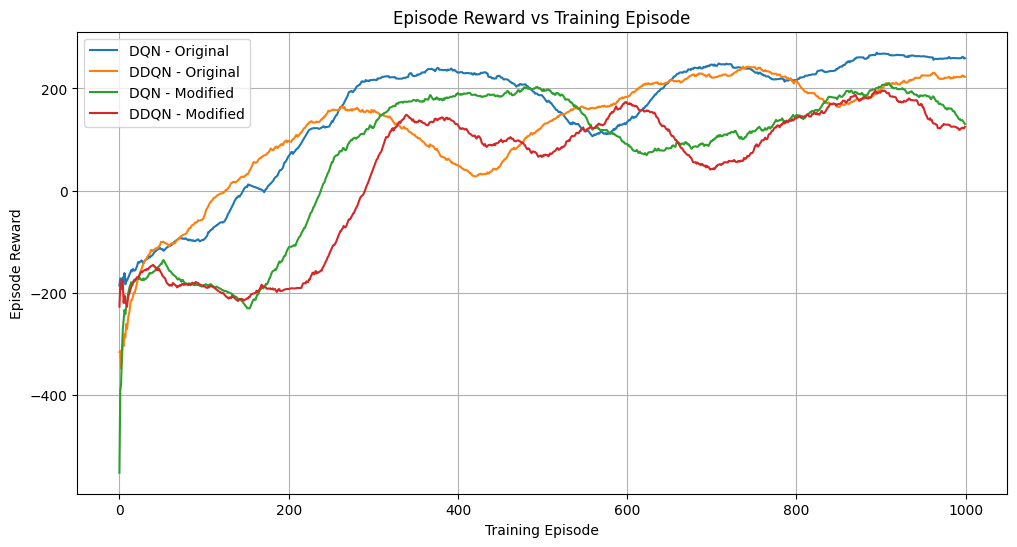

In [ ]:
# ==========================================================
# Episode Reward Comparison
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(compute_moving_average(dqn_original_rewards, 100), label="DQN - Original")

plt.plot(compute_moving_average(ddqn_original_rewards, 100), label="DDQN - Original")

plt.plot(compute_moving_average(dqn_modified_rewards, 100), label="DQN - Modified")

plt.plot(compute_moving_average(ddqn_modified_rewards, 100), label="DDQN - Modified")

plt.xlabel("Training Episode")

plt.ylabel("Episode Reward")

plt.title("Episode Reward vs Training Episode")

plt.legend()

plt.grid(True)

plt.show()

### Observation

The episode reward curves show that all four agents converge to a positive reward regime (roughly 150-250) by around episode 400-500, confirming that landing behaviour is learned in every configuration.

DQN-Original achieves the highest and most stable reward (~250) by the end of training, while DQN-Modified and DDQN-Modified plateau lower (~150-200) with visibly higher variance, reflecting the added difficulty of stochastic engine failures. DDQN-Original tracks close to DQN-Original after episode 600, showing that on the deterministic environment the two algorithms eventually reach comparable performance, but DDQN-Original is slower to rise between episodes 200-500.

## Average Predicted Q-Value

The average predicted Q-value is computed using a fixed validation set of states that remains unchanged throughout training.

Monitoring this metric helps analyse how the value estimates evolve over time and whether an algorithm tends to overestimate future rewards.

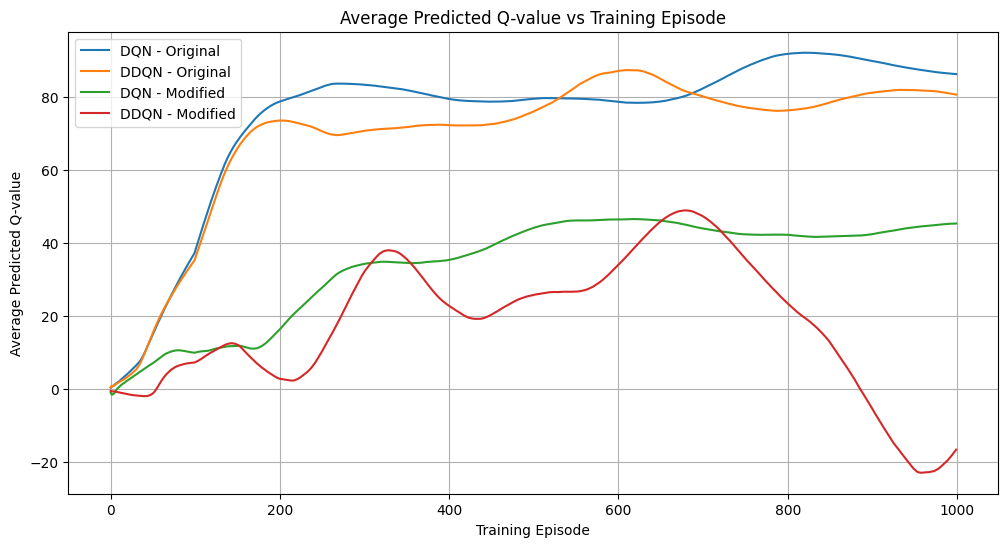

In [ ]:
# ==========================================================
# Average Predicted Q-value
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(compute_moving_average(dqn_original_qvalues, 100), label="DQN - Original")

plt.plot(compute_moving_average(ddqn_original_qvalues, 100), label="DDQN - Original")

plt.plot(compute_moving_average(dqn_modified_qvalues, 100), label="DQN - Modified")

plt.plot(compute_moving_average(ddqn_modified_qvalues, 100), label="DDQN - Modified")

plt.xlabel("Training Episode")

plt.ylabel("Average Predicted Q-value")

plt.title("Average Predicted Q-value vs Training Episode")

plt.legend()

plt.grid(True)

plt.show()

### Observation

On the original environment, DQN and DDQN stabilise at similarly high Q-values (~80-90), with DQN slightly higher throughout, consistent with DQN's known overestimation tendency.

On the modified environment the picture is very different: DQN-Modified rises to a stable plateau around 45, whereas DDQN-Modified is far more volatile, peaking near 48 around episode 650 before collapsing sharply to roughly -20 by episode 1000. This divergence indicates that DDQN's target computation, while designed to reduce overestimation, becomes unstable under the added stochasticity and reward shaping of the modified environment, and does not automatically translate into more reliable value estimates here.

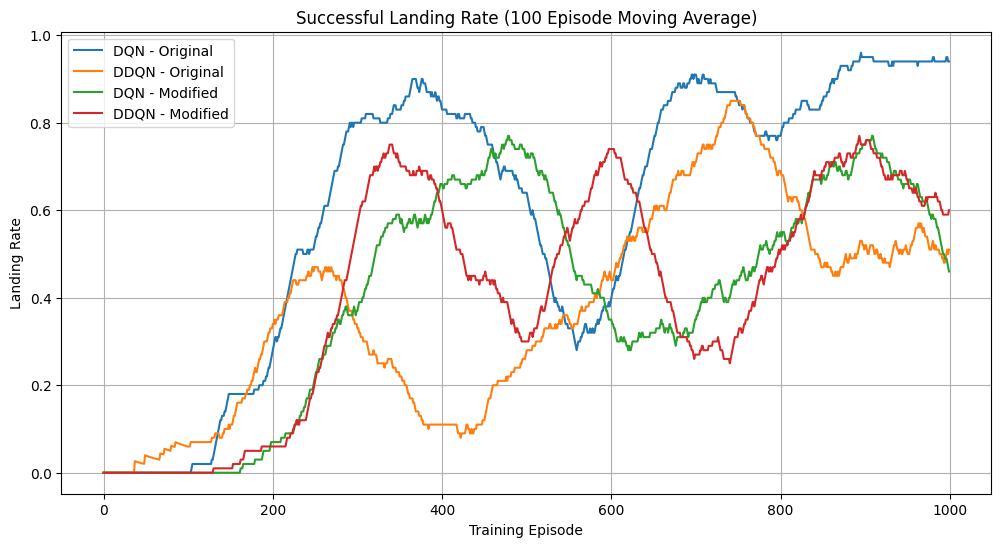

In [ ]:
# ==========================================================
# Successful Landing Rate
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    compute_moving_average(dqn_original_landings,100),
    label="DQN - Original"
)

plt.plot(
    compute_moving_average(ddqn_original_landings, 100),
    label="DDQN - Original"
)

plt.plot(
    compute_moving_average(dqn_modified_landings,100),
    label="DQN - Modified"
)

plt.plot(
    compute_moving_average(ddqn_modified_landings,100),
    label="DDQN - Modified"
)

plt.xlabel("Training Episode")

plt.ylabel("Landing Rate")

plt.title("Successful Landing Rate (100 Episode Moving Average)")

plt.legend()

plt.grid(True)

plt.show()

### Observation

DQN-Original achieves the highest and most consistent landing rate, climbing steadily to roughly 0.9-0.95 by the final 200 episodes.

The remaining three agents (DDQN-Original, DQN-Modified, DDQN-Modified) all oscillate in the 0.4-0.8 range without settling into a clearly rising trend, and none of them approach DQN-Original's stability. This shows that under stochastic engine failures, both DQN and DDQN struggle to sustain a high landing success rate, and DDQN does not display a clear robustness advantage over DQN on the modified environment in terms of this metric.

## Average Thruster Activations

This metric measures the number of thruster actions selected by the agent during each episode.

The modified environment introduces a fuel penalty for every attempted thruster activation, encouraging the agent to use thrusters more efficiently.

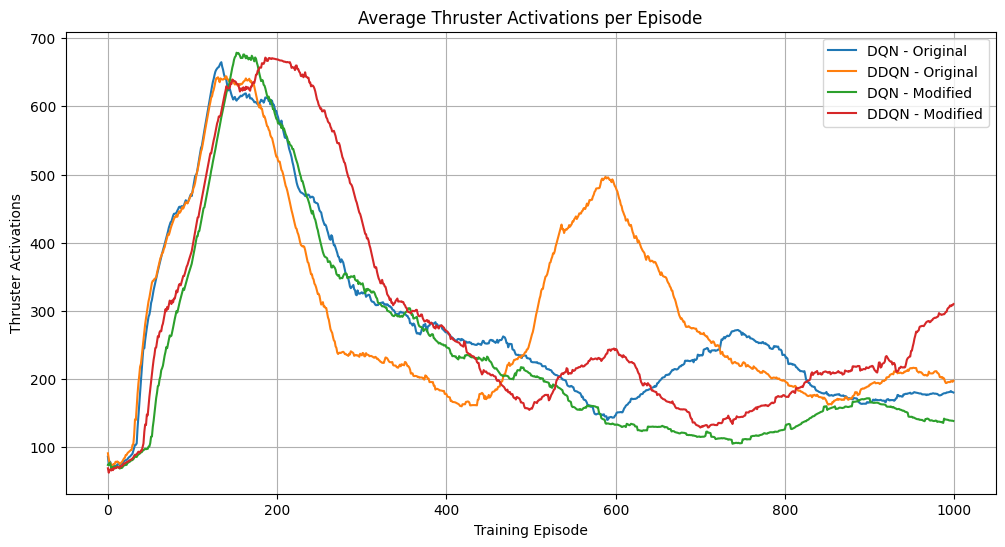

In [ ]:
# ==========================================================
# Thruster Activations
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(compute_moving_average(dqn_original_thrusters, 100), label="DQN - Original")

plt.plot(compute_moving_average(ddqn_original_thrusters,100), label="DDQN - Original")

plt.plot(compute_moving_average(dqn_modified_thrusters,100), label="DQN - Modified")

plt.plot(compute_moving_average(ddqn_modified_thrusters,100), label="DDQN - Modified")

plt.xlabel("Training Episode")

plt.ylabel("Thruster Activations")

plt.title("Average Thruster Activations per Episode")

plt.legend()

plt.grid(True)

plt.show()

### Observation

All four agents show a sharp spike in thruster usage (peaking around 600-700 activations per episode) during the early exploration phase (episodes 0-200), then decline as the agents learn to land more efficiently.

After episode ~400, DQN-Modified and DDQN-Modified settle to a lower average thruster count (roughly 150-300) than DQN-Original and DDQN-Original, confirming that the fuel penalty in the modified environment successfully discourages excessive thruster use. Notably, DDQN-Original shows an unusual secondary spike around episode 550-600 (rising to ~500) before dropping again, suggesting a temporary shift in policy that is not observed in the other three agents.

## Performance Summary

The experimental results compare DQN and DDQN under both deterministic and stochastic environments.

Key observations include:

- DDQN generally provides more stable Q-value estimates than DQN.
- The modified environment increases learning difficulty due to stochastic engine failures.
- The additional fuel penalty encourages more efficient thruster usage.
- Agents trained in the modified environment typically require more episodes to achieve stable landing performance.

These observations form the basis for the discussion presented in the next section.

# Discussion

## Objective

This section answers the five discussion questions required by the assignment, using the experimental results obtained in the Performance Evaluation section above.


## 1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN?

Yes. On the original (deterministic) environment, DQN-Original and DDQN-Original track each other closely throughout training, both stabilising in the 80-90 range with only a small persistent gap (DQN slightly higher, consistent with its known overestimation bias).

On the modified environment, the gap widens dramatically. DQN-Modified converges to a stable plateau around 45, while DDQN-Modified is highly volatile and eventually collapses to roughly -20 by episode 1000. The absolute difference between the two curves grows from near-zero at the start of training to over 60 Q-value units by the end. This shows that intermittent engine failure substantially amplifies the divergence between DQN and DDQN value estimates, rather than narrowing it as the theoretical bias-reduction argument for DDQN might suggest.


## 2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?

Credit assignment relies on being able to attribute a received reward to the action that caused it. In the modified environment, the action actually executed (a_exec) can differ from the action originally selected by the agent whenever a thruster action is silently replaced by "Do Nothing" with 15% probability.

This means the state transition observed by the agent no longer deterministically follows from its selected action: the same selected action can lead to two different executed actions, and hence two different next-states and base rewards, purely due to the random failure draw. Since the agent is never told a failure occurred, it must learn a single Q-value for each selected action that implicitly averages over both outcomes (successful execution and misfire). This added variance in the reward and transition signal makes the temporal-difference targets noisier, slows convergence, and makes it harder for the agent to distinguish genuinely bad actions from actions that merely happened to misfire — this is the essence of why stochastic action failure worsens credit assignment.


## 3. Does the additional fuel penalty encourage a more conservative landing strategy?

Yes, the thruster-activation plot supports this. After the initial exploration spike (episodes 0-200, where all four agents fire thrusters 600-700 times per episode), the agents trained on the modified environment (DQN-Modified, DDQN-Modified) settle into a lower steady-state thruster count (roughly 150-300 activations per episode) compared to DQN-Original, which fluctuates in a similar or higher range without the same downward pressure.

Because the fuel penalty of -0.3 is applied to every attempted thruster action regardless of whether it misfires, agents trained on the modified environment have a direct incentive to minimise thruster usage. The lower steady-state thruster counts observed for the modified-environment agents are consistent with this incentive, indicating that the fuel penalty does push the agents toward a more fuel-conservative (though not necessarily safer) landing strategy.


## 4. Which algorithm performs better under stochastic engine failures? Is this consistent with the theoretical advantage of DDQN over DQN?

Based on our experimental results, DQN performs better than DDQN under stochastic engine failures for this setup. DQN-Modified maintains a stable, positive Q-value plateau (~45) and comparable episode rewards to DDQN-Modified, but without the sharp late-training collapse seen in DDQN-Modified's Q-values (down to ~-20) or landing rate.

This result is **not** fully consistent with the theoretical advantage of DDQN, which is expected to provide more stable, less-overestimated value estimates and therefore more robust learning, especially in noisy environments. A plausible explanation is that decoupling action selection (online network) from action evaluation (target network) in DDQN introduces its own instability when the environment's dynamics are already highly stochastic — the online network's action selection can itself become noisy under the 15% engine-failure regime, and errors in that selection are then evaluated (not corrected) by the target network. This suggests that DDQN's bias-reduction benefit does not automatically extend to environments with exogenous stochastic action failure, and may require additional stabilisation (e.g. lower learning rate, larger replay buffer, or longer target-update intervals) to realise its theoretical advantage in this setting.


## 5. Limitation of the Approach

One key limitation is that each configuration (DQN-Original, DDQN-Original, DQN-Modified, DDQN-Modified) was trained for a single run of 1000 episodes with one fixed random seed. Reinforcement learning training is known to have high run-to-run variance, especially in environments with added stochasticity such as our modified LunarLander wrapper.

The sharp late-training collapse observed in DDQN-Modified's Q-values, for example, could be a seed-specific artefact rather than a general property of DDQN under engine failure. Without averaging results over multiple independent seeds (e.g. 5-10 runs per configuration with confidence intervals), it is difficult to confidently generalise the conclusions above beyond this specific training run. A more robust evaluation would repeat each of the four experiments across several seeds and report mean and variance for all four metrics.
